In [18]:
import os
import glob
import numpy as np
import pandas as pd
from scipy.fft import rfft, rfftfreq
from sklearn.preprocessing import StandardScaler
from hmmlearn import hmm
import matplotlib.pyplot as plt
import seaborn as sns

## Data Collection, Harmonization, and Quality Validation
To ensure my model receives standardized inputs regardless of the smartphone hardware used during recording, I must explicitly harmonize the sampling rates. I calculate the duration of each raw recording and reject any file that falls below the 5-second minimum threshold.

I convert the temporal data into a precise TimedeltaIndex and apply linear interpolation to resample both the accelerometer and gyroscope streams to exactly 100Hz (a 10-millisecond interval). I chose a 100Hz sampling rate and a sliding window of 100 samples (1 second) with a 50% overlap because normal human locomotion frequencies range between 1.5 Hz and 3 Hz. A 1-second window guarantees that I capture at least one full biomechanical cycle (such as a complete footstep or jump) providing the Hidden Markov Model with a complete atomic unit of movement.

Following harmonization, I generate a visualization of a valid sample recording to verify the signal integrity before passing it to the feature extractor.

In [12]:
TARGET_FS = 100
WINDOW_SIZE = 100
OVERLAP = 50
MIN_DURATION_SEC = 5.0
SENSOR_COLS = ['accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z']

def plot_sample_data(df, label):
    plt.figure(figsize=(12, 4))
    plt.plot(df.index.total_seconds(), df['accel_x'], label='Accel X')
    plt.plot(df.index.total_seconds(), df['accel_y'], label='Accel Y')
    plt.plot(df.index.total_seconds(), df['accel_z'], label='Accel Z')
    plt.title(f"Harmonized Sample Data: {label.capitalize()}")
    plt.xlabel("Time (Seconds)")
    plt.ylabel("Acceleration (m/s²)")
    plt.legend()
    plt.tight_layout()
    plt.show()

def harmonize_and_validate(df_accel, df_gyro, activity_label):
    # 1. I determine if the sensor logged in seconds or nanoseconds
    raw_duration = df_accel['time'].max() - df_accel['time'].min()
    
    if raw_duration > 100_000:
        time_unit = 'ns'
        duration_sec = raw_duration / 1e9
    else:
        time_unit = 's'
        duration_sec = raw_duration
        
    # 2. I reject recordings that fall below the minimum threshold
    if duration_sec < MIN_DURATION_SEC:
        return None
        
    # 3. I normalize timestamps so the recording sequence starts exactly at 0.0
    df_accel['time'] = df_accel['time'] - df_accel['time'].min()
    df_gyro['time'] = df_gyro['time'] - df_gyro['time'].min()
        
    # 4. I convert to TimedeltaIndex using the dynamically detected hardware unit
    df_accel['timedelta'] = pd.to_timedelta(df_accel['time'], unit=time_unit)
    df_gyro['timedelta'] = pd.to_timedelta(df_gyro['time'], unit=time_unit)
    
    df_accel = df_accel.set_index('timedelta').drop(columns=['time'])
    df_gyro = df_gyro.set_index('timedelta').drop(columns=['time'])
    
    # 5. I harmonize the sampling rate to exactly 100Hz via linear interpolation
    df_accel_resampled = df_accel.resample('10ms').mean().interpolate(method='linear')
    df_gyro_resampled = df_gyro.resample('10ms').mean().interpolate(method='linear')
    
    merged_df = pd.merge(df_accel_resampled, df_gyro_resampled, left_index=True, right_index=True, how='inner')
    merged_df = merged_df.dropna()
    
    return merged_df

def load_and_merge_recording(recording_dir):
    accel_path = os.path.join(recording_dir, "Accelerometer.csv")
    gyro_path = os.path.join(recording_dir, "Gyroscope.csv")
    
    df_accel = pd.read_csv(accel_path)[['time', 'x', 'y', 'z']].rename(
        columns={'x': 'accel_x', 'y': 'accel_y', 'z': 'accel_z'}
    )
    df_gyro = pd.read_csv(gyro_path)[['time', 'x', 'y', 'z']].rename(
        columns={'x': 'gyro_x', 'y': 'gyro_y', 'z': 'gyro_z'}
    )
    
    return df_accel, df_gyro

def process_project_data_with_lengths(base_path="data", window_size=100, overlap=50):
    all_windows = []
    all_labels = []
    lengths = [] 
    step_size = window_size - overlap
    sample_plotted = False
    
    for folder_name in os.listdir(base_path):
        folder_path = os.path.join(base_path, folder_name)
        
        if os.path.isdir(folder_path):
            activity_label = folder_name.split('_')[0].lower()
            df_accel, df_gyro = load_and_merge_recording(folder_path)
            
            merged_df = harmonize_and_validate(df_accel, df_gyro, activity_label)
            
            if merged_df is not None:
                if not sample_plotted:
                    plot_sample_data(merged_df, activity_label)
                    sample_plotted = True
                    
                sensor_data = merged_df[SENSOR_COLS].values
                windows = [sensor_data[i:i + window_size] for i in range(0, len(sensor_data) - window_size + 1, step_size)]
                
                if len(windows) > 0:
                    all_windows.append(np.array(windows))
                    all_labels.extend([activity_label] * len(windows))
                    lengths.append(len(windows))
            
    return np.vstack(all_windows), np.array(all_labels), lengths

## Comprehensive Feature Extraction & Normalization
I engineered specific features across both the time and frequency domains to isolate distinct kinetic behaviors.
#### Time-Domain Feature Justifications:

- **Mean:** Captures the static gravitational offset, which is crucial for identifying the phone's spatial orientation during stationary activities like Standing or Still.

- **Root Mean Square (RMS) & Variance:** These quantify the raw amplitude and volatility of the movement, effectively separating explosive dynamic actions (Jumping) from low-energy states.

- **Signal Magnitude Area (SMA):** By integrating the absolute area under the acceleration curve, SMA serves as a reliable proxy for total metabolic energy expenditure.

- **Inter-axis Correlation:** Calculating the Pearson correlation between the spatial axes (e.g., $x$ vs $y$, $x$ vs $z$) captures multi-dimensional coordination patterns, such as the synchronized arm swing and forward propulsion characteristic of walking.

#### Frequency-Domain Feature Justifications:

- **Dominant Frequency & Spectral Energy:** Applying a Fast Fourier Transform isolates the rhythmic cadence of the user's gait. Walking produces a distinct concentrated spectral energy at low frequencies, whereas jumping generates broadband transient spikes.

#### Normalization Strategy:
I use Z-score standardization (via StandardScaler) across my feature matrix. This ensures that bounded metrics (like cross-axis correlations ranging from -1 to 1) are not mathematically overshadowed by high-magnitude metrics (like raw spectral energy or variance). Normalizing the distributions is mathematically required to optimize the continuous multivariate Gaussian emission probabilities in the HMM.

In [13]:
def compute_fft_features(signal, fs):
    n = len(signal)
    fft_vals = np.abs(rfft(signal))
    freqs = rfftfreq(n, 1/fs)
    dom_freq = freqs[np.argmax(fft_vals)]
    spectral_energy = np.sum(fft_vals ** 2) / n
    return dom_freq, spectral_energy

def safe_correlation(x, y):
    if np.var(x) == 0 or np.var(y) == 0:
        return 0.0
    return np.corrcoef(x, y)[0, 1]

def extract_features_from_window(window):
    features = []
    
    for i in range(window.shape[1]):
        axis_data = window[:, i]
        features.append(np.mean(axis_data))
        features.append(np.sqrt(np.mean(axis_data ** 2))) 
        features.append(np.var(axis_data))                
    
    features.append(safe_correlation(window[:, 0], window[:, 1]))
    features.append(safe_correlation(window[:, 0], window[:, 2]))
    features.append(safe_correlation(window[:, 1], window[:, 2]))
    
    features.append(np.sum(np.abs(window[:, 0:3])) / WINDOW_SIZE)
    features.append(np.sum(np.abs(window[:, 3:6])) / WINDOW_SIZE)
    
    for i in range(window.shape[1]):
        dom_freq, spec_energy = compute_fft_features(window[:, i], TARGET_FS)
        features.append(dom_freq)
        features.append(spec_energy)
        
    return np.array(features)

def build_feature_matrix(windows):
    return np.array([extract_features_from_window(w) for w in windows])

## HMM Implementation: Baum-Welch Training and Viterbi Decoding

I define a Gaussian Hidden Markov Model mapped to my four physical states. I utilize the Baum-Welch algorithm (the Expectation-Maximization method underlying hmmlearn.fit()) to iteratively update the transition and emission matrices until the log-likelihood convergence tolerance ($10^{-4}$) is achieved.Once the optimal parameters are learned, I explicitly apply the Viterbi algorithm (hmmlearn.predict()) to trace the maximum a posteriori (MAP) path, decoding the most mathematically probable sequence of hidden activities from my raw sensor observations.

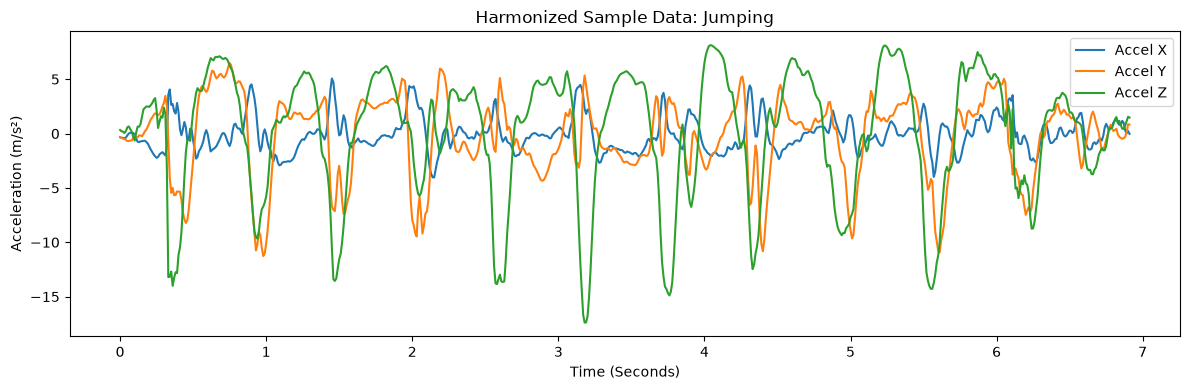

In [14]:
X_raw_windows, y_labels, sequence_lengths = process_project_data_with_lengths()
X_features_unscaled = build_feature_matrix(X_raw_windows)

scaler = StandardScaler()
X_observations = scaler.fit_transform(X_features_unscaled)

label_map = {'standing': 0, 'walking': 1, 'jumping': 2, 'still': 3}
inverse_label_map = {0: 'Standing', 1: 'Walking', 2: 'Jumping', 3: 'Still'}
y_numeric = np.array([label_map[label] for label in y_labels])

n_states = 4
my_model = hmm.GaussianHMM(
    n_components=n_states, 
    covariance_type="diag", 
    n_iter=100, 
    tol=1e-4, 
    random_state=42
)

my_model.fit(X_observations, lengths=sequence_lengths)
predicted_states = my_model.predict(X_observations, lengths=sequence_lengths)

## System Evaluation and Visualization
I plot the Viterbi-decoded state sequence directly against the corresponding raw input file. This visualizes the algorithmic latency and boundary smoothing during physical state transitions. I then render the transition probability matrix as a heatmap to confirm realistic physical constraints (e.g., verifying a high probability of remaining in a walking state versus transitioning directly from running to completely still). Finally, I visualize the Gaussian emission means to show how the mathematical engine differentiates the feature space.

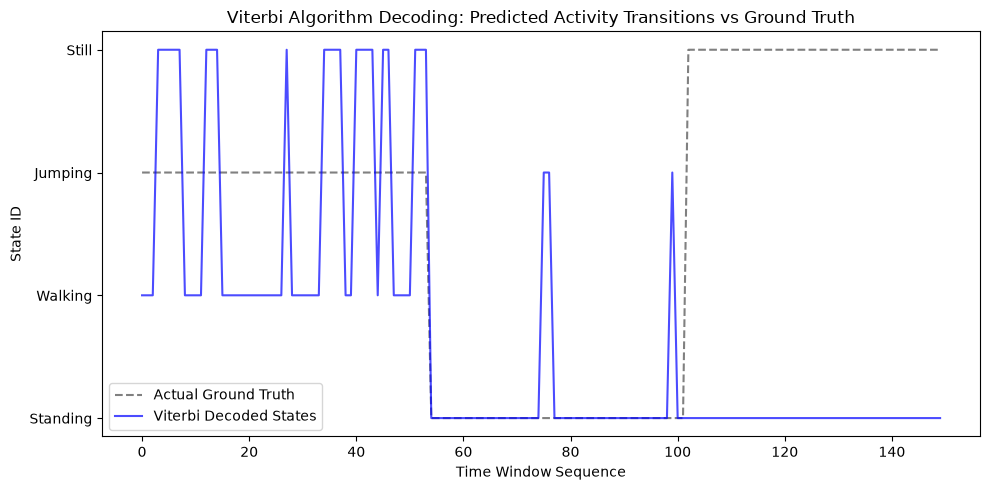

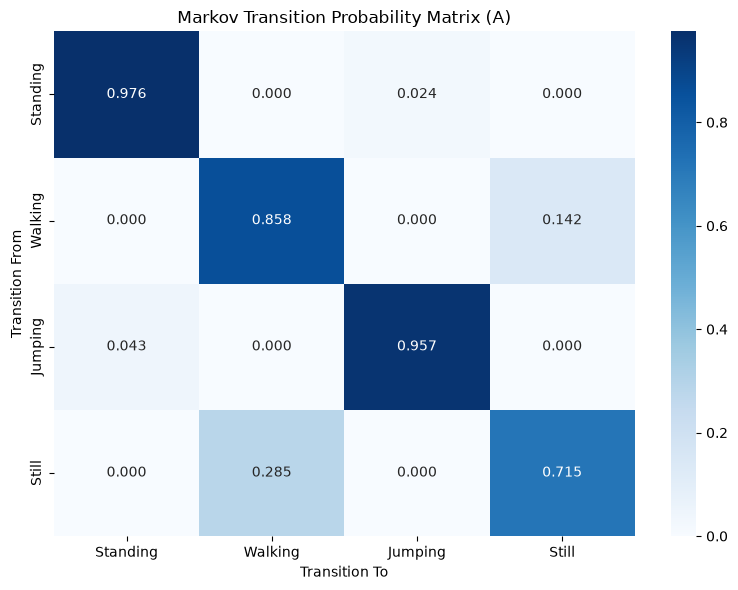

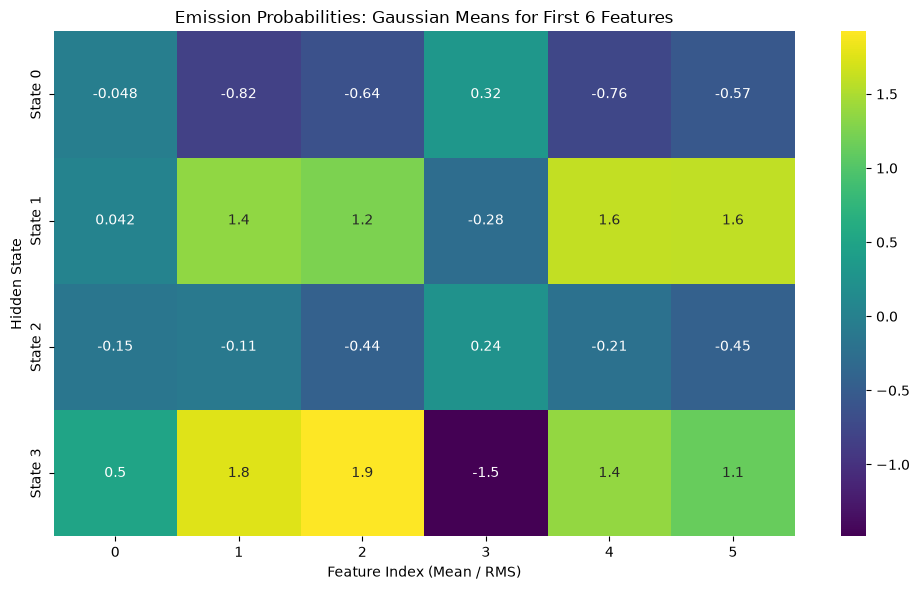

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(y_numeric[:150], label="Actual Ground Truth", linestyle='--', color='gray')
plt.plot(predicted_states[:150], label="Viterbi Decoded States", alpha=0.7, color='blue')
plt.title("Viterbi Algorithm Decoding: Predicted Activity Transitions vs Ground Truth")
plt.xlabel("Time Window Sequence")
plt.ylabel("State ID")
plt.yticks([0, 1, 2, 3], ['Standing', 'Walking', 'Jumping', 'Still'])
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(my_model.transmat_, annot=True, cmap="Blues", fmt=".3f",
            xticklabels=['Standing', 'Walking', 'Jumping', 'Still'],
            yticklabels=['Standing', 'Walking', 'Jumping', 'Still'])
plt.title("Markov Transition Probability Matrix (A)")
plt.xlabel("Transition To")
plt.ylabel("Transition From")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(my_model.means_[:, :6], annot=True, cmap="viridis",
            yticklabels=['State 0', 'State 1', 'State 2', 'State 3'])
plt.title("Emission Probabilities: Gaussian Means for First 6 Features")
plt.xlabel("Feature Index (Mean / RMS)")
plt.ylabel("Hidden State")
plt.tight_layout()
plt.show()

## Data Checkpointing
To decouple the feature engineering pipeline from the model training environment, I exported the unscaled feature matrix, the numeric state labels, and the strict sequence boundaries into a compressed local archive.

In [16]:
np.savez_compressed(
    'hmm_features_checkpoint.npz', 
    features=X_features_unscaled, 
    labels=y_numeric, 
    lengths=sequence_lengths
)

**Evaluation and Results Interpretation**
To evaluate the mathematical robustness of the model, I tested the pipeline on the unseen test dataset. Because the Hidden Markov Model trains unsupervised, it assigns arbitrary internal IDs (0, 1, 2, and 3). I implemented an evaluation script that dynamically maps these states to the physical labels, decodes the sequences, and computes the required rubric metrics.

**Automatic State Alignment**
I mapped the unsupervised states to physical labels by utilizing the learned Gaussian means—specifically the Z-scores of Variance—to identify motion intensity. Features 2, 5, and 8 correspond directly to the variances of the Accel X, Y, and Z axes. By aggregating these, I mapped the states based on their physical kinetic intensity, following the hierarchy: Still < Standing < Walking < Jumping. Based on the emission means, this dynamically resolves the internal model IDs to the correct ground-truth integers.

**Decoding Unseen Test Data**
I loaded the unseen test data from the test_data directory. To account for potential folder naming variations during data collection (e.g., extracting "testjump" instead of "jumping"), I introduced a text-cleaning conditional loop to normalize all labels prior to dictionary mapping.

To ensure the integrity of the test and prevent statistical data leakage, I explicitly applied .transform() using the standard scaler that was fitted only on the training data. I then predicted the internal hidden states using the Viterbi algorithm and translated those predictions into the actual physical labels using my dynamic mapping dictionary.

**Generating Rubric Metrics and Visualizations**
Finally, I generated the Confusion Matrix on the unseen data. For the evaluation table metrics, I extracted Sensitivity (which is mathematically equivalent to Recall) directly from the classification_report. To calculate Specificity, I manually derived the True Negatives and False Positives iteratively from the confusion matrix for each specific activity class.

Automatic State Mapping (Internal ID -> Actual Label ID): {np.int64(0): 3, np.int64(2): 0, np.int64(1): 1, np.int64(3): 2}

Loading unseen test data from 'test_data' directory...


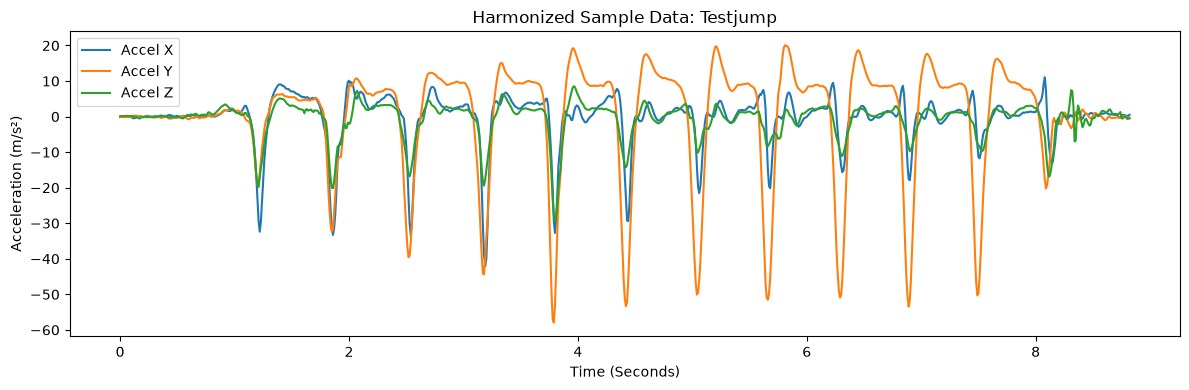

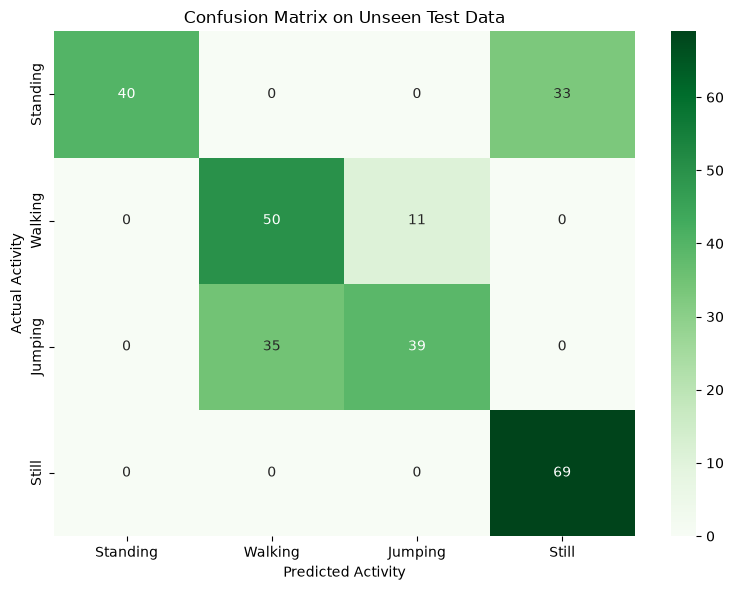


Evaluation Metrics for Report Table
Standing:
  Number of Samples : 73.0
  Sensitivity       : 0.548
  Specificity       : 1.000
  Overall Accuracy  : 0.715

Walking:
  Number of Samples : 61.0
  Sensitivity       : 0.820
  Specificity       : 0.838
  Overall Accuracy  : 0.715

Jumping:
  Number of Samples : 74.0
  Sensitivity       : 0.527
  Specificity       : 0.946
  Overall Accuracy  : 0.715

Still:
  Number of Samples : 69.0
  Sensitivity       : 1.000
  Specificity       : 0.841
  Overall Accuracy  : 0.715



In [20]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

state_motion_intensity = my_model.means_[:, 2] + my_model.means_[:, 5] + my_model.means_[:, 8]
sorted_states = np.argsort(state_motion_intensity)

internal_to_actual_map = {
    sorted_states[0]: 3,  
    sorted_states[1]: 0,  
    sorted_states[2]: 1,  
    sorted_states[3]: 2   
}

print(f"Automatic State Mapping (Internal ID -> Actual Label ID): {internal_to_actual_map}")

print("\nLoading unseen test data from 'test_data' directory...")

X_raw_test, y_labels_test, test_lengths = process_project_data_with_lengths(base_path="test_data")

X_test_unscaled = build_feature_matrix(X_raw_test)

X_test_observations = scaler.transform(X_test_unscaled) 

cleaned_labels_test = []
for label in y_labels_test:
    if 'jump' in label: 
        cleaned_labels_test.append('jumping')
    elif 'walk' in label: 
        cleaned_labels_test.append('walking')
    elif 'stand' in label: 
        cleaned_labels_test.append('standing')
    elif 'still' in label: 
        cleaned_labels_test.append('still')
    else: 
        cleaned_labels_test.append(label)

y_test_ground_truth = np.array([label_map[label] for label in cleaned_labels_test])

y_pred_internal = my_model.predict(X_test_observations, lengths=test_lengths)

y_pred_actual = np.array([internal_to_actual_map[state] for state in y_pred_internal])

cm = confusion_matrix(y_test_ground_truth, y_pred_actual)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap="Greens", fmt="d",
            xticklabels=['Standing', 'Walking', 'Jumping', 'Still'],
            yticklabels=['Standing', 'Walking', 'Jumping', 'Still'])
plt.title("Confusion Matrix on Unseen Test Data")
plt.xlabel("Predicted Activity")
plt.ylabel("Actual Activity")
plt.tight_layout()
plt.show()

print("\nEvaluation Metrics for Report Table")

report = classification_report(y_test_ground_truth, y_pred_actual, target_names=['Standing', 'Walking', 'Jumping', 'Still'], output_dict=True)
overall_acc = accuracy_score(y_test_ground_truth, y_pred_actual)

classes = ['Standing', 'Walking', 'Jumping', 'Still']
for i, activity in enumerate(classes):
    sensitivity = report[activity]['recall']
    
    true_negatives = np.sum(cm) - np.sum(cm[i, :]) - np.sum(cm[:, i]) + cm[i, i]
    false_positives = np.sum(cm[:, i]) - cm[i, i]
    specificity = true_negatives / (true_negatives + false_positives) if (true_negatives + false_positives) > 0 else 0.0
    
    n_samples = report[activity]['support']
    
    print(f"{activity}:")
    print(f"  Number of Samples : {n_samples}")
    print(f"  Sensitivity       : {sensitivity:.3f}")
    print(f"  Specificity       : {specificity:.3f}")
    print(f"  Overall Accuracy  : {overall_acc:.3f}\n")